# Full-Sweep Substantive Analyses

Companion to `diagnostics.ipynb`. Sections S1–S8 characterize FPR/TPR behavior, detection latency, and per-condition TPR surfaces for the two recorded scores (`surp2`, `sus1`) using the **corrected** `sus1` variance throughout.

Figures and tables are saved to `results/full_sweep/analyses/substantive/`.

In [19]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.dataset as dset


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path().resolve())
    while p != p.parent:
        if (p / 'experiments' / 'full_sweep').exists():
            return p
        p = p.parent
    raise RuntimeError('repo root not found')


ROOT = _find_repo_root()
SWEEP_DIR = ROOT / 'results' / 'full_sweep'
TRAJ_DIR = SWEEP_DIR / 'trajectories'
SIMS_DIR = SWEEP_DIR / 'simulations'
OUT_DIR = SWEEP_DIR / 'analyses' / 'substantive'
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_ALPHA_1 = True  # drop alpha=1 sims from all downstream analyses

ALPHA_REPR = [2.0, 3.0, 10.0]
if EXCLUDE_ALPHA_1:
    ALPHA_REPR = [a for a in ALPHA_REPR if a != 1.0]
C_VALUES = [2.0, 2.5, 3.0, 3.5]
SCORES = ['surp2', 'sus1']
SCORE_COLORS = {'surp2': 'tab:blue', 'sus1': 'tab:orange'}
T_MAX = 150

TRAJ_COLS = [
    'cell_id', 'sim_id', 'round', 'theta_star', 'psi_true', 'alpha',
    'surp2_score', 'surp2_Sus', 'surp2_sigma_bar2',
    'sus1_score', 'sus1_Sus', 'sus1_sigma_bar2_corrected',
]


def load_trajectories(columns=TRAJ_COLS) -> pd.DataFrame:
    ds = dset.dataset(str(TRAJ_DIR), format='parquet', partitioning='hive')
    return ds.to_table(columns=columns).to_pandas()


def alpha_colors(alphas) -> dict:
    ranked = sorted({float(a) for a in alphas})
    cmap = plt.get_cmap('viridis')
    n = max(1, len(ranked) - 1)
    return {a: cmap(i / n) for i, a in enumerate(ranked)}


def c_tag(c: float) -> str:
    return f'{c:g}'


def sigma_bar_col(score: str) -> str:
    return 'surp2_sigma_bar2' if score == 'surp2' else 'sus1_sigma_bar2_corrected'


def save(fig, name: str):
    fig.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight')

## Load trajectories and build simulation-level summary

For each `(cell_id, sim_id)` compute `tau(c)` and a `crossed` flag for every `(score, c)` combination. Cached to `substantive/sim_summary.parquet`.

In [13]:
SUMMARY_PATH = OUT_DIR / 'sim_summary.parquet'


def build_sim_summary(df: pd.DataFrame) -> pd.DataFrame:
    keys = ['cell_id', 'sim_id', 'theta_star', 'psi_true', 'alpha']
    base = (df[keys].drop_duplicates()
                   .sort_values(['cell_id', 'sim_id'])
                   .reset_index(drop=True))
    # per-row thresholds & crossed flags, then first crossing per (cell, sim)
    r = df['round'].to_numpy()
    for score in SCORES:
        sus = df[f'{score}_Sus'].to_numpy()
        sb = df[sigma_bar_col(score)].to_numpy()
        sb_over_t = np.sqrt(np.maximum(sb, 0.0) / np.maximum(r, 1))
        for c in C_VALUES:
            crossed = sus > c * sb_over_t
            hits = df.loc[crossed, ['cell_id', 'sim_id', 'round']]
            tau = (hits.groupby(['cell_id', 'sim_id'])['round']
                       .min()
                       .rename(f'tau_{score}_c{c_tag(c)}')
                       .reset_index())
            base = base.merge(tau, on=['cell_id', 'sim_id'], how='left')
            base[f'crossed_{score}_c{c_tag(c)}'] = base[f'tau_{score}_c{c_tag(c)}'].notna()
    return base


df = load_trajectories()
print(f'trajectory rows: {len(df):,}')

if SUMMARY_PATH.exists():
    sim_summary = pd.read_parquet(SUMMARY_PATH)
    print(f'loaded cached sim_summary ({len(sim_summary):,} sims)')
else:
    sim_summary = build_sim_summary(df)
    sim_summary.to_parquet(SUMMARY_PATH)
    print(f'built sim_summary ({len(sim_summary):,} sims) → {SUMMARY_PATH}')

if EXCLUDE_ALPHA_1:
    df = df[df['alpha'] != 1.0].reset_index(drop=True)
    sim_summary = sim_summary[sim_summary['alpha'] != 1.0].reset_index(drop=True)
    print(f'after excluding alpha=1: {len(df):,} trajectory rows, {len(sim_summary):,} sims')

COLORS = alpha_colors(df['alpha'].unique())
sim_summary.head()

trajectory rows: 8,910,000
loaded cached sim_summary (59,400 sims)
after excluding alpha=1: 8,100,000 trajectory rows, 54,000 sims


,cell_id,sim_id,theta_star,psi_true,alpha,tau_surp2_c2,crossed_surp2_c2,tau_surp2_c2.5,crossed_surp2_c2.5,tau_surp2_c3,...,tau_surp2_c3.5,crossed_surp2_c3.5,tau_sus1_c2,crossed_sus1_c2,tau_sus1_c2.5,crossed_sus1_c2.5,tau_sus1_c3,crossed_sus1_c3,tau_sus1_c3.5,crossed_sus1_c3.5
0,1,0,0.1,inf,1.5,8.0,True,23.0,True,23.0,...,23.0,True,NaN,False,NaN,False,NaN,False,NaN,False
1,1,1,0.1,inf,1.5,NaN,False,NaN,False,NaN,...,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False
2,1,2,0.1,inf,1.5,17.0,True,17.0,True,NaN,...,NaN,False,3.0,True,3.0,True,3.0,True,NaN,False
3,1,3,0.1,inf,1.5,NaN,False,NaN,False,NaN,...,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False
4,1,4,0.1,inf,1.5,NaN,False,NaN,False,NaN,...,NaN,False,NaN,False,NaN,False,NaN,False,NaN,False


## S1 — Headline FPR/TPR table

One-glance summary of the FPR/TPR tradeoff across `(score, c)`. Pooled across all `theta_star` and `alpha`.

In [14]:
def headline_table(sim_summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for score in SCORES:
        for c in C_VALUES:
            col = f'crossed_{score}_c{c_tag(c)}'
            fpr = sim_summary.loc[sim_summary['psi_true'] == 'inf', col].mean()
            tpr_p = sim_summary.loc[sim_summary['psi_true'] == 'pers+', col].mean()
            tpr_m = sim_summary.loc[sim_summary['psi_true'] == 'pers-', col].mean()
            tpr_avg = 0.5 * (tpr_p + tpr_m)
            rows.append({
                'score': score, 'c': c,
                'FPR': fpr,
                'TPR_pers+': tpr_p,
                'TPR_pers-': tpr_m,
                'TPR_avg': tpr_avg,
                'TPR_avg - FPR': tpr_avg - fpr,
            })
    return pd.DataFrame(rows)


s1 = headline_table(sim_summary)
s1.to_csv(OUT_DIR / 'S1_headline_table.csv', index=False)
s1.round(3)

,score,c,FPR,TPR_pers+,TPR_pers-,TPR_avg,TPR_avg - FPR
0,surp2,2.0,0.234,0.743,0.740,0.741,0.508
1,surp2,2.5,0.121,0.699,0.700,0.700,0.578
2,surp2,3.0,0.069,0.667,0.669,0.668,0.598
3,surp2,3.5,0.034,0.635,0.636,0.635,0.601
4,sus1,2.0,0.251,0.997,0.996,0.997,0.746
5,sus1,2.5,0.129,0.991,0.990,0.991,0.861
6,sus1,3.0,0.065,0.980,0.978,0.979,0.914
7,sus1,3.5,0.035,0.962,0.960,0.961,0.926


**S1 observations**

- Best `(score, c)` by `TPR_avg - FPR`? *(fill in after inspection)*
- Any row with `FPR < 0.05` and `TPR_avg > 0.80`?

## S2 — FPR vs alpha

How does FPR depend on rationality? Pooled across `theta_star`.

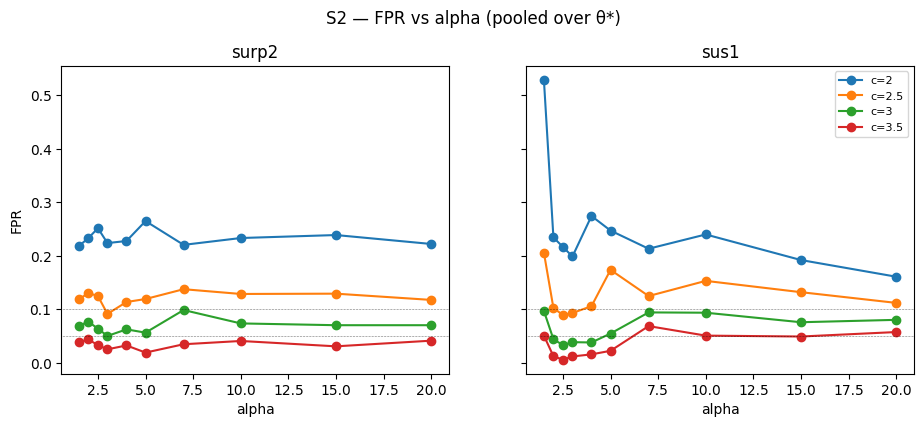

In [16]:
null = sim_summary[sim_summary['psi_true'] == 'inf']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, score in zip(axes, SCORES):
    for c in C_VALUES:
        col = f'crossed_{score}_c{c_tag(c)}'
        g = null.groupby('alpha')[col].mean().reset_index()
        ax.plot(g['alpha'], g[col], marker='o', label=f'c={c:g}')
    #ax.set_xscale('log')
    ax.axhline(0.05, color='k', lw=0.4, ls=':')
    ax.axhline(0.10, color='k', lw=0.4, ls=':')
    ax.set_title(score)
    ax.set_xlabel('alpha')
axes[0].set_ylabel('FPR')
axes[-1].legend(fontsize=8)
fig.suptitle('S2 — FPR vs alpha (pooled over θ*)', y=1.02)
save(fig, 'S2_fpr_vs_alpha.png')
plt.show()

**S2 observations**

- Does FPR decrease monotonically with `alpha`?
- Is there an `alpha` above which FPR ≤ 5% for some `c`?

## S3 — TPR vs alpha

Does high rationality help or hurt detection of persuasion? Pooled across `theta_star`, split by `psi_true`.

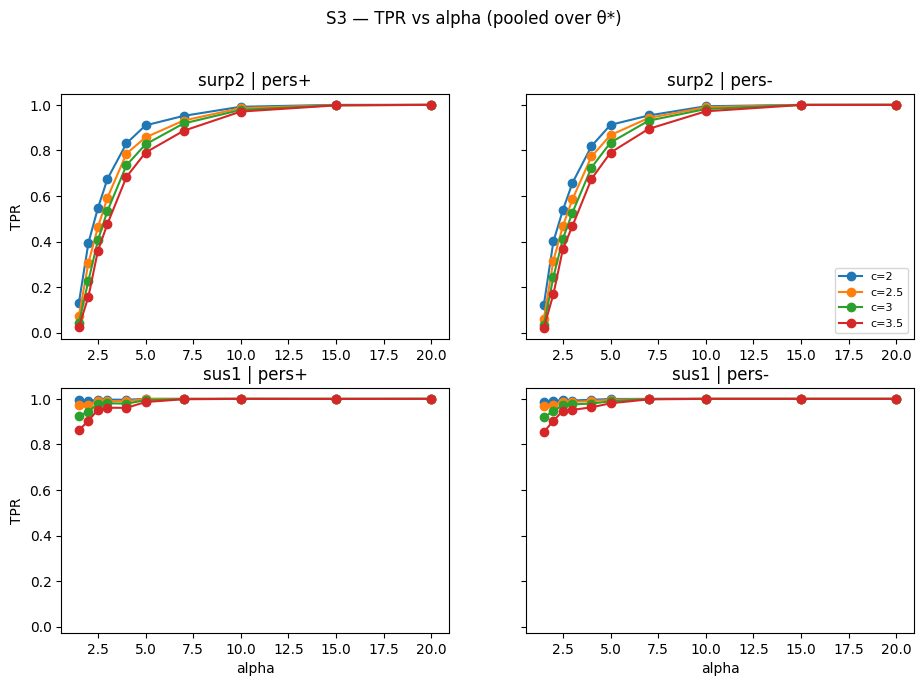

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
for i, score in enumerate(SCORES):
    for j, psi in enumerate(['pers+', 'pers-']):
        ax = axes[i, j]
        sub = sim_summary[sim_summary['psi_true'] == psi]
        for c in C_VALUES:
            col = f'crossed_{score}_c{c_tag(c)}'
            g = sub.groupby('alpha')[col].mean().reset_index()
            ax.plot(g['alpha'], g[col], marker='o', label=f'c={c:g}')
        #ax.set_xscale('log')
        ax.set_title(f'{score} | {psi}')
        if i == 1:
            ax.set_xlabel('alpha')
        if j == 0:
            ax.set_ylabel('TPR')
axes[0, -1].legend(fontsize=8)
fig.suptitle('S3 — TPR vs alpha (pooled over θ*)', y=1.00)
save(fig, 'S3_tpr_vs_alpha.png')
plt.show()

**S3 observations**

- Does TPR degrade at low or high `alpha`?
- Do `pers+` and `pers-` behave symmetrically?

## S4 — Detection latency distributions

When detection happens at `c=2`, how fast? Violin plots of `tau` conditional on crossing. Annotation above each violin gives the crossing rate.

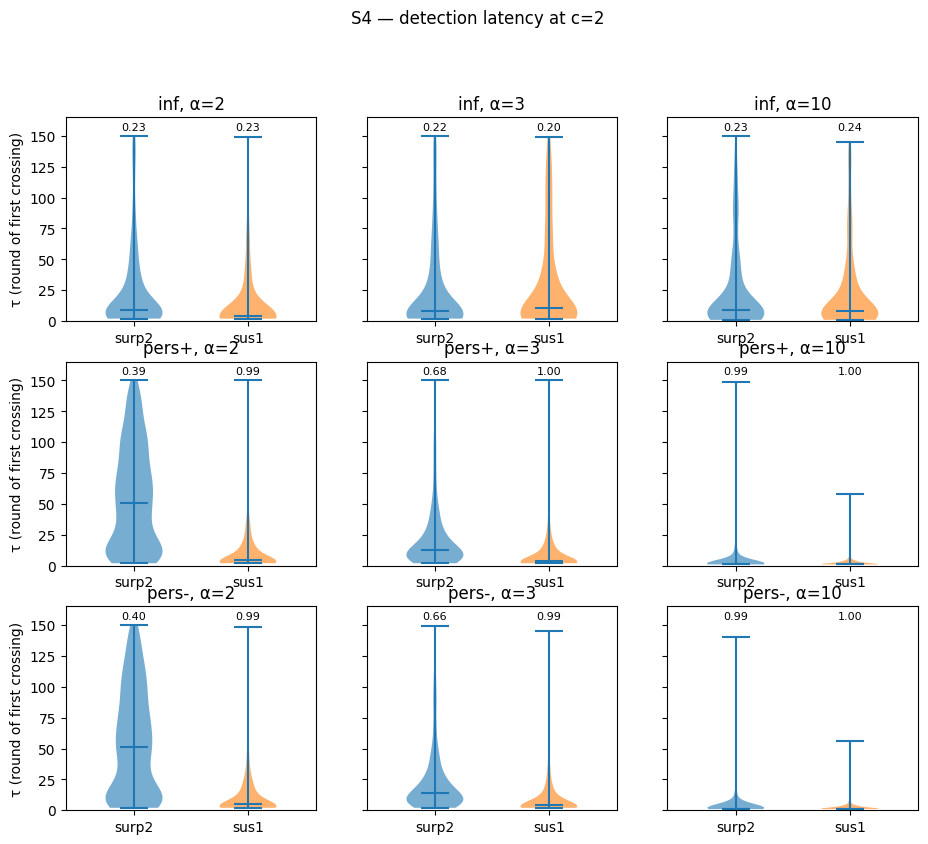

In [20]:
C4 = 2.0
psis = ['inf', 'pers+', 'pers-']

fig, axes = plt.subplots(3, 3, figsize=(11, 9), sharey=True)
for i, psi in enumerate(psis):
    for j, a in enumerate(ALPHA_REPR):
        ax = axes[i, j]
        data, labels, rates, positions = [], [], [], []
        for k, score in enumerate(SCORES):
            sub = sim_summary[(sim_summary['psi_true'] == psi)
                              & (sim_summary['alpha'] == a)]
            taus = sub[f'tau_{score}_c{c_tag(C4)}'].dropna().to_numpy()
            rate = len(taus) / max(len(sub), 1)
            labels.append(score)
            rates.append(rate)
            if len(taus) >= 2 and np.std(taus) > 0:
                data.append(taus)
                positions.append(k + 1)
        if data:
            parts = ax.violinplot(data, positions=positions, showmedians=True)
            for p, pos in zip(parts['bodies'], positions):
                p.set_facecolor(SCORE_COLORS[SCORES[pos - 1]])
                p.set_alpha(0.6)
        for k, rate in enumerate(rates):
            ax.text(k + 1, T_MAX * 1.02, f'{rate:.2f}',
                    ha='center', va='bottom', fontsize=8)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(labels)
        ax.set_xlim(0.4, 2.6)
        ax.set_ylim(0, T_MAX * 1.1)
        ax.set_title(f'{psi}, α={a:g}')
        if j == 0:
            ax.set_ylabel('τ (round of first crossing)')
fig.suptitle(f'S4 — detection latency at c={C4:g}', y=1.00)
save(fig, 'S4_latency_distributions.png')
plt.show()

**S4 observations**

- How does `tau` shift with `alpha`? Faster at high `alpha`?
- Do `surp2` and `sus1` differ in median latency?

## S5 — The `alpha*` table

For each `(score, c, FPR_target)`: smallest `alpha` at which pooled FPR is below the target, plus TPR and median `tau` at that `alpha`.

In [21]:
FPR_TARGETS = [0.05, 0.10]

null = sim_summary[sim_summary['psi_true'] == 'inf']
pos = sim_summary[sim_summary['psi_true'].isin(['pers+', 'pers-'])]

rows = []
for score in SCORES:
    for c in C_VALUES:
        fcol = f'crossed_{score}_c{c_tag(c)}'
        tcol = f'tau_{score}_c{c_tag(c)}'
        fpr_by_a = null.groupby('alpha')[fcol].mean().sort_index()
        for target in FPR_TARGETS:
            below = fpr_by_a[fpr_by_a < target]
            if len(below) == 0:
                rows.append({'score': score, 'c': c, 'FPR_target': target,
                             'alpha_star': np.nan, 'TPR': np.nan, 'median_tau': np.nan})
                continue
            alpha_star = float(below.index.min())
            sub = pos[pos['alpha'] == alpha_star]
            tpr = sub[fcol].mean()
            taus = sub[tcol].dropna()
            med = float(taus.median()) if len(taus) else np.nan
            rows.append({'score': score, 'c': c, 'FPR_target': target,
                         'alpha_star': alpha_star, 'TPR': tpr, 'median_tau': med})

s5 = pd.DataFrame(rows)
s5.to_csv(OUT_DIR / 'S5_alpha_star_table.csv', index=False)
s5.round(3)

,score,c,FPR_target,alpha_star,TPR,median_tau
0,surp2,2.0,0.05,NaN,NaN,NaN
1,surp2,2.0,0.10,NaN,NaN,NaN
2,surp2,2.5,0.05,NaN,NaN,NaN
3,surp2,2.5,0.10,3.0,0.589,20.0
4,surp2,3.0,0.05,NaN,NaN,NaN
5,surp2,3.0,0.10,1.5,0.038,13.0
6,surp2,3.5,0.05,1.5,0.024,13.0
7,surp2,3.5,0.10,1.5,0.024,13.0
8,sus1,2.0,0.05,NaN,NaN,NaN
9,sus1,2.0,0.10,NaN,NaN,NaN


**S5 observations**

- Is there an `(alpha, c)` with controlled FPR (≤5%) and high TPR?
- How does the FPR-controlling `alpha*` trade against detection latency?

## S6 — Per-condition TPR heatmaps

Where in `(theta_star, alpha)` space does detection succeed vs fail? Columns: `pers+`, `pers-`, and the average. `c=2`.

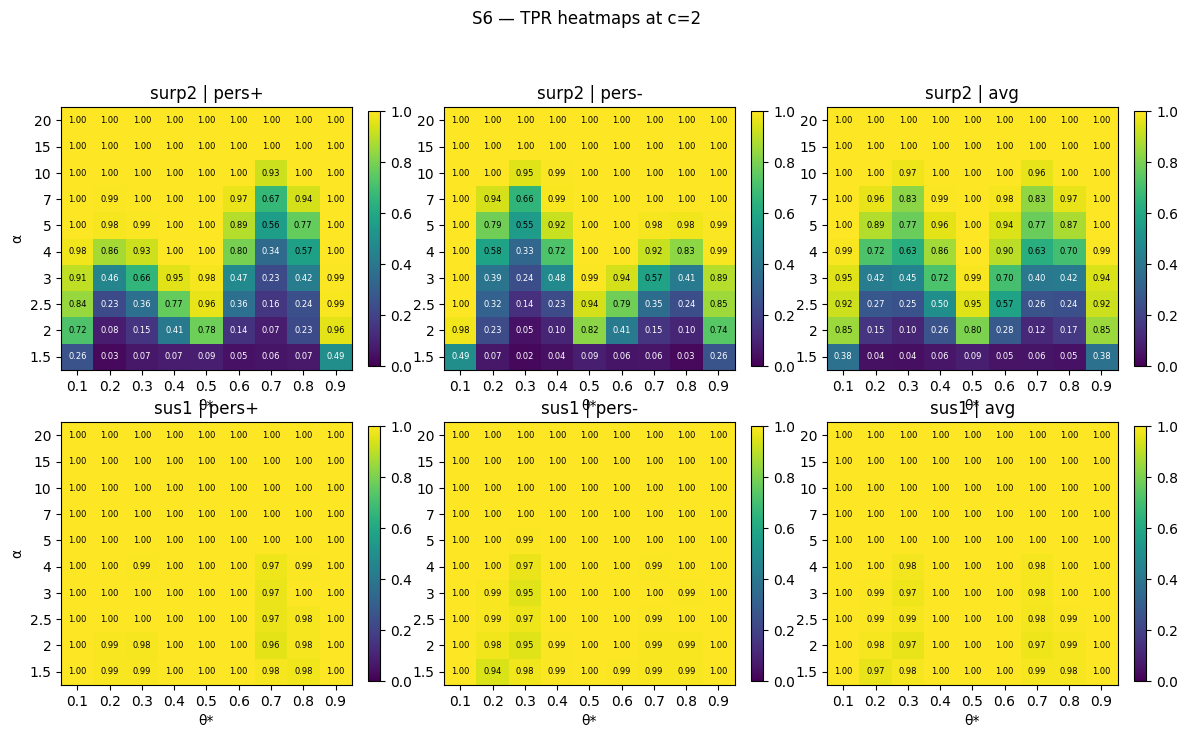

In [22]:
C6 = 2.0
col_psi = [('pers+', 'pers+'), ('pers-', 'pers-'), ('avg', 'avg')]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for i, score in enumerate(SCORES):
    fcol = f'crossed_{score}_c{c_tag(C6)}'
    for j, (psi_key, title) in enumerate(col_psi):
        ax = axes[i, j]
        if psi_key == 'avg':
            sub = sim_summary[sim_summary['psi_true'].isin(['pers+', 'pers-'])]
        else:
            sub = sim_summary[sim_summary['psi_true'] == psi_key]
        pivot = (sub.groupby(['alpha', 'theta_star'])[fcol]
                    .mean().unstack().sort_index())
        im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                       cmap='viridis', vmin=0, vmax=1)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{v:g}' for v in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{v:g}' for v in pivot.index])
        for ii in range(pivot.shape[0]):
            for jj in range(pivot.shape[1]):
                v = pivot.values[ii, jj]
                ax.text(jj, ii, f'{v:.2f}', ha='center', va='center',
                        fontsize=6, color='white' if v < 0.5 else 'black')
        ax.set_title(f'{score} | {title}')
        ax.set_xlabel('θ*')
        if j == 0:
            ax.set_ylabel('α')
        plt.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle(f'S6 — TPR heatmaps at c={C6:g}', y=1.01)
save(fig, 'S6_tpr_heatmaps.png')
plt.show()

**S6 observations**

- Which `(θ*, α)` regions are easy/hard?
- Are `pers+` and `pers-` symmetric across `θ*`?

## S7 — Score trajectory comparison

Qualitative picture of how `surp2_Sus` and `sus1_Sus` evolve vs their thresholds under representative conditions. `alpha=3`, `theta_star ∈ {0.2, 0.5, 0.8}`, `c=2`. Bands are 95% CI on the mean across 200 sims.

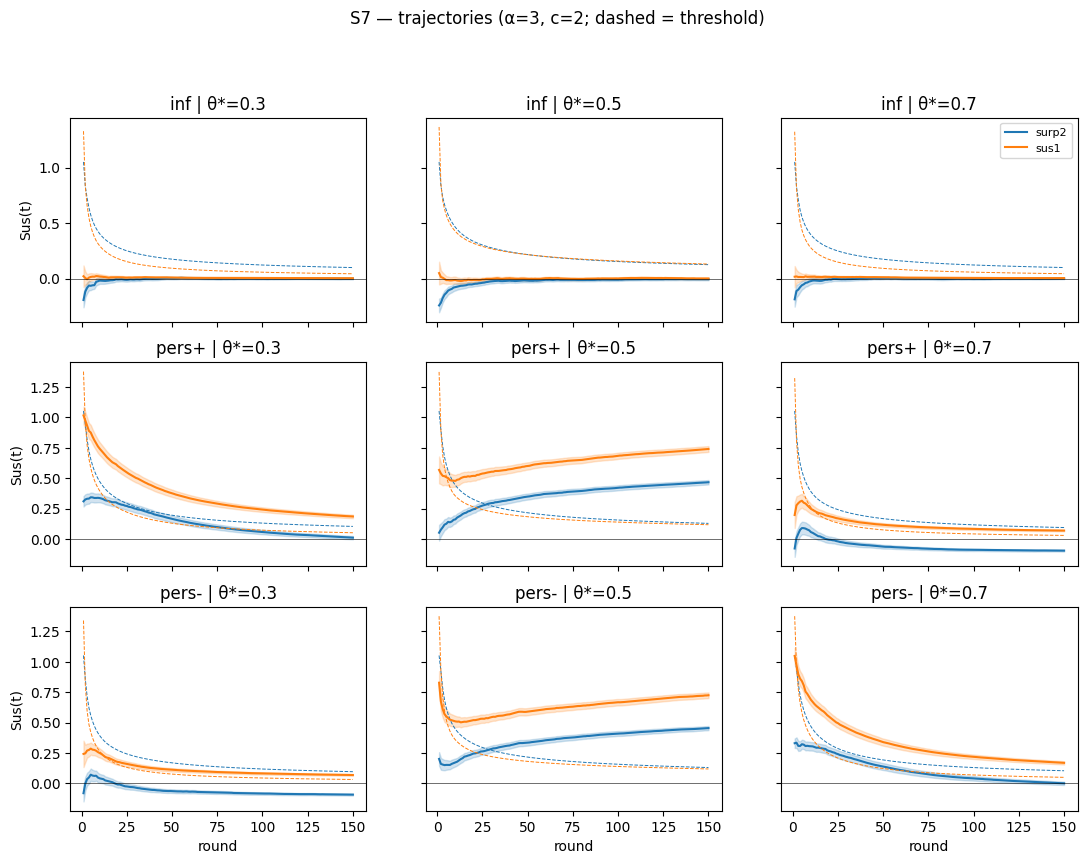

In [24]:
THETAS_S7 = [0.3, 0.5, 0.7]
ALPHA_S7 = 3.0
C7 = 2.0

traj_S7 = df[(df['alpha'] == ALPHA_S7) & (df['theta_star'].isin(THETAS_S7))]
psis = ['inf', 'pers+', 'pers-']

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey='row')
for i, psi in enumerate(psis):
    for j, th in enumerate(THETAS_S7):
        ax = axes[i, j]
        sub = traj_S7[(traj_S7['psi_true'] == psi) & (traj_S7['theta_star'] == th)]
        for score in SCORES:
            color = SCORE_COLORS[score]
            sus_col = f'{score}_Sus'
            sb_col = sigma_bar_col(score)
            g = (sub.groupby('round')
                     .agg(mean=(sus_col, 'mean'),
                          std=(sus_col, 'std'),
                          mean_sb=(sb_col, 'mean'),
                          n=(sus_col, 'count'))
                     .reset_index())
            ci = 1.96 * g['std'] / np.sqrt(g['n'])
            ax.plot(g['round'], g['mean'], color=color, label=score)
            ax.fill_between(g['round'], g['mean'] - ci, g['mean'] + ci,
                            color=color, alpha=0.2)
            thr = C7 * np.sqrt(np.maximum(g['mean_sb'], 0.0) / np.maximum(g['round'], 1))
            ax.plot(g['round'], thr, '--', color=color, lw=0.7)
        ax.axhline(0, color='k', lw=0.4)
        ax.set_title(f'{psi} | θ*={th:g}')
        if i == 2:
            ax.set_xlabel('round')
        if j == 0:
            ax.set_ylabel('Sus(t)')
axes[0, -1].legend(fontsize=8, loc='upper right')
fig.suptitle(f'S7 — trajectories (α={ALPHA_S7:g}, c={C7:g}; dashed = threshold)',
             y=1.00)
save(fig, 'S7_trajectories.png')
plt.show()

**S7 observations**

- How do the two scores approach their thresholds under each condition?
- Qualitative differences between `surp2` and `sus1`?

## S8 — Score correlation

Pearson correlation between `surp2_score` and `sus1_score` over all rounds and sims, split by `psi_true`. Hex-binned because of point density (~3M per panel).

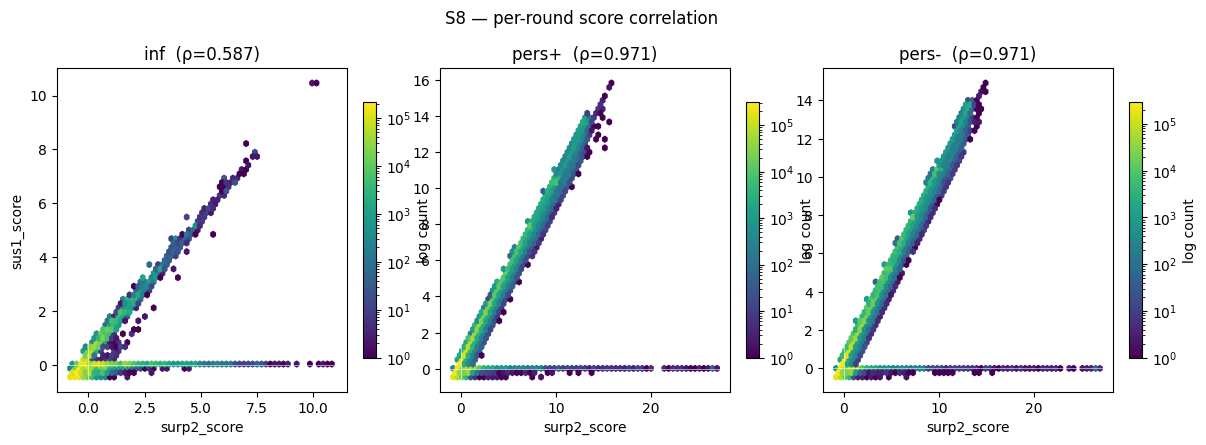

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, psi in zip(axes, ['inf', 'pers+', 'pers-']):
    sub = df[df['psi_true'] == psi]
    x = sub['surp2_score'].to_numpy()
    y = sub['sus1_score'].to_numpy()
    rho = float(np.corrcoef(x, y)[0, 1])
    hb = ax.hexbin(x, y, gridsize=60, cmap='viridis', bins='log', mincnt=1)
    ax.axhline(0, color='w', lw=0.4)
    ax.axvline(0, color='w', lw=0.4)
    ax.set_title(f'{psi}  (ρ={rho:.3f})')
    ax.set_xlabel('surp2_score')
    if psi == 'inf':
        ax.set_ylabel('sus1_score')
    plt.colorbar(hb, ax=ax, fraction=0.04, label='log count')
fig.suptitle('S8 — per-round score correlation', y=1.02)
save(fig, 'S8_score_correlation.png')
plt.show()

**S8 observations**

- Are the two scores capturing the same signal, or meaningfully different aspects?
- Does the correlation differ between `inf` and persuasive regimes?

## Summary

- Best `(score, c)` combination and the trade-off it represents: *(fill in)*
- Where detection works / fails across `(θ*, α)`: *(fill in)*
- Implications for the report narrative: *(fill in)*